[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luleu96/GenAIinDD_Exercises/blob/work/Exercises/Exercise_3/MCMC_new.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# we want to predict if the next day is rainy or sunny based on todays weather
def simulate_weather_markov_chain(n_days, initial_state='S'):
    # Define transition probabilities
    transition_probs = {
        'R': {'R': 0.5, 'S': 0.5},  # P(R|R) = 0.5, P(S|R) = 0.5
        'S': {'R': 0.1, 'S': 0.9}   # P(R|S) = 0.1, P(S|S) = 0.9
    }

    # Initialize variables
    states = []
    current_state = initial_state

    # Run simulation
    for _ in range(n_days):
        states.append(current_state)
        # Get next state based on transition probabilities
        prob = np.random.random()
        if prob < transition_probs[current_state]['R']:
            current_state = 'R'
        else:
            current_state = 'S'
    return states

In [ ]:
# count the occurences of each day and calculate the conditional probabilites as well as the overall probabilities of a given weather event
def analyze_results(states):
    # Calculate state probabilities
    counter = Counter(states)
    total = len(states)
    probabilities = {state: count/total for state, count in counter.items()}

    # Calculate transition probabilities
    transitions = {'R': {'R': 0, 'S': 0}, 'S': {'R': 0, 'S': 0}}
    for i in range(len(states)-1):
        current_state = states[i]
        next_state = states[i+1]
        transitions[current_state][next_state] += 1

    # Normalize transition counts to probabilities
    for state in transitions:
        total = sum(transitions[state].values())
        if total > 0:  # Avoid division by zero
            for next_state in transitions[state]:
                transitions[state][next_state] /= total

    return probabilities, transitions

In [ ]:
# plot results
def plot_convergence(states):
    running_rainy_prob = []
    rainy_count = 0

    # Calculate running probability of rainy days
    for i, state in enumerate(states, 1):
        if state == 'R':
            rainy_count += 1
        running_rainy_prob.append(rainy_count / i)

    # Create plot
    plt.figure(figsize=(10, 6))
    plt.plot(running_rainy_prob)
    plt.title('Convergence of Probability of Rainy Day')
    plt.xlabel('Number of Days')
    plt.ylabel('Probability of Rain')
    plt.grid(True)
    plt.show()

In [16]:
# Run simulation
n_days = 100
states = simulate_weather_markov_chain(n_days)
probabilities, transitions = analyze_results(states)


In [17]:
# Print results
print("\nSteady State Probabilities:")
print(f"P(Rainy) = {probabilities.get('R', 0):.3f}")
print(f"P(Sunny) = {probabilities.get('S', 0):.3f}")

print("\nCalculated Transition Probabilities:")
print(f"P(R|R) = {transitions['R']['R']:.3f}")
print(f"P(S|R) = {transitions['R']['S']:.3f}")
print(f"P(R|S) = {transitions['S']['R']:.3f}")
print(f"P(S|S) = {transitions['S']['S']:.3f}")


Steady State Probabilities:
P(Rainy) = 0.190
P(Sunny) = 0.810

Calculated Transition Probabilities:
P(R|R) = 0.526
P(S|R) = 0.474
P(R|S) = 0.113
P(S|S) = 0.887


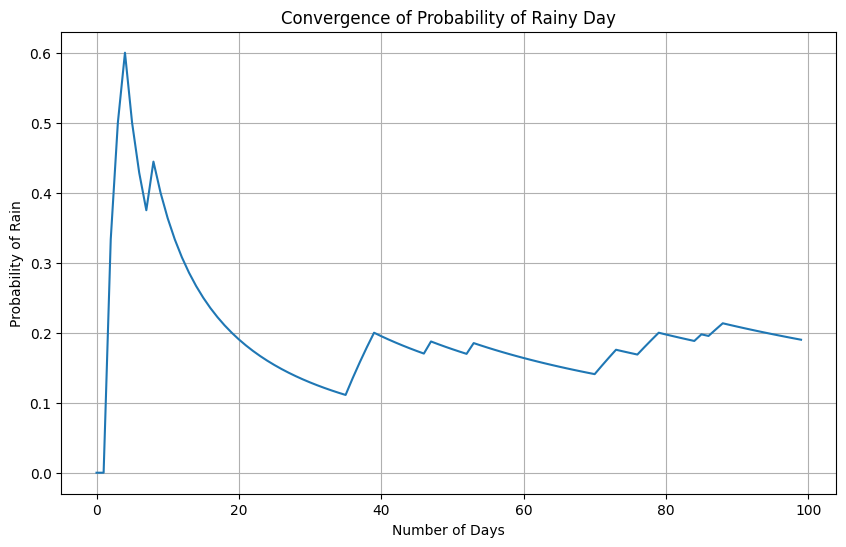

In [18]:
plot_convergence(states)